Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Dataset Overview:
Total dataset size: (50000, 2)
Columns: Index(['review', 'sentiment'], dtype='object')

Sentiment Distribution:
Positive reviews: 25000 (50.00%)
Negative reviews: 25000 (50.00%)

Training Data Shape: (800, 2)
Testing Data Shape: (200, 2)

Example Reviews:

Positive review: This is what happens when you're living in China and the local video store is running thin on English-language titlesyou are blessed with this work of what appears to be, yes, Romanian cinema. Nevertheless, I think that it has real comedic potential.<br /><br />Spoilers technically follow:<br /><br />Though I don't think that it would in fact spoil anyone's viewing pleasure to ask why a film set in a casino has a scene of beach archery, even in flashback. That mystery, and many other conundrums, remain to be exploited by desperate comedians, perhaps when they're stuck in

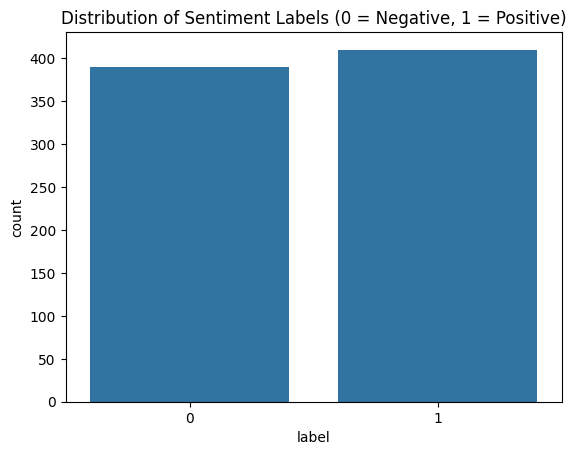

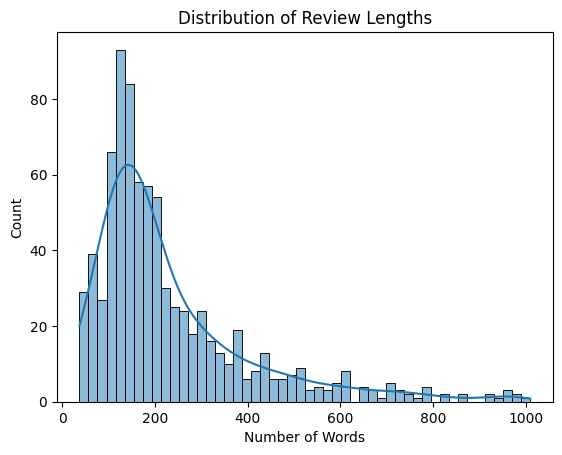

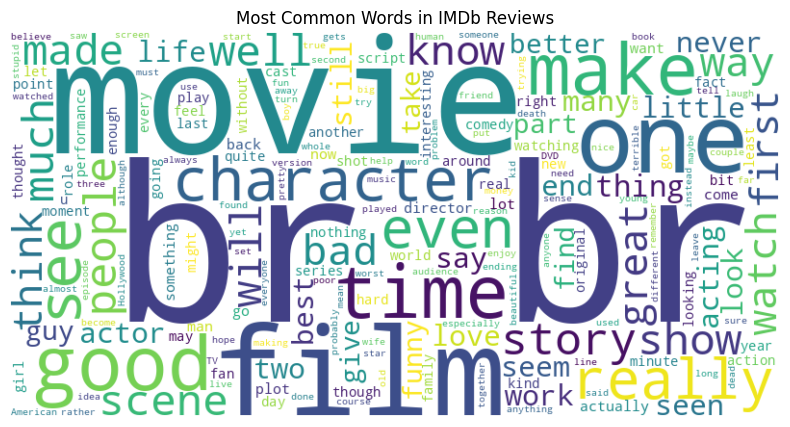


Review Length Statistics:
Average review length: 232.53 words
Maximum review length: 1010 words
Minimum review length: 37 words


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Predicted Sentiment: Negative

Review: Terrible film. I couldn't wait for it to end.


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

Predicted Sentiment: Positive


In [ ]:
# ============================================
# Install required libraries (run once in Colab)
# ============================================
!pip install transformers simpletransformers wordcloud


# ============================================
# Import necessary libraries
# ============================================
import logging
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from simpletransformers.classification import ClassificationModel, ClassificationArgs
from google.colab import drive


# ============================================
# Mount Google Drive
# ============================================
drive.mount('/content/drive')


# ============================================
# Load IMDb dataset from Google Drive
# ============================================
# file_path = "/content/drive/My Drive/Colab Notebooks/IMDB_Dataset.csv" # Original path causing FileNotFoundError

# TODO: Please verify the correct path to your IMDB_Dataset.csv file in Google Drive
# Example: file_path = "/content/drive/My Drive/Your_Folder/IMDB_Dataset.csv"
file_path = "/content/drive/My Drive/Colab Notebooks/IMDB_Dataset.csv" # Placeholder - UPDATE THIS PATH IF NEEDED
df = pd.read_csv(file_path)


# ============================================
# Display dataset details
# ============================================
print("\nDataset Overview:")
print(f"Total dataset size: {df.shape}")
print(f"Columns: {df.columns}")


# ============================================
# Data preprocessing
# ============================================

# Rename 'sentiment' column to 'label'
df = df.rename(columns={"sentiment": "label"})

# Convert label to integer (positive = 1, negative = 0)
df["label"] = df["label"].astype(int)

# Handle missing values
df = df.dropna()

# Rename columns to SimpleTransformers format
df.columns = ["text", "label"]


# ============================================
# Display sentiment distribution
# ============================================
print("\nSentiment Distribution:")
print(f"Positive reviews: {(df['label'] == 1).sum()} ({(df['label'] == 1).mean() * 100:.2f}%)")
print(f"Negative reviews: {(df['label'] == 0).sum()} ({(df['label'] == 0).mean() * 100:.2f}%)")


# ============================================
# Optional: Subset dataset for faster training
# ============================================
df = df.sample(n=1000, random_state=42)


# ============================================
# Train-test split
# ============================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"\nTraining Data Shape: {train_df.shape}")
print(f"Testing Data Shape: {test_df.shape}")


# ============================================
# Show example reviews
# ============================================
print("\nExample Reviews:")
print("\nPositive review:", train_df[train_df["label"] == 1]["text"].iloc[0])
print("\nNegative review:", train_df[train_df["label"] == 0]["text"].iloc[0])


# ============================================
# Exploratory Data Analysis (EDA)
# ============================================
print("\nPerforming Exploratory Data Analysis (EDA)...")

# 1. Label distribution
sns.countplot(x="label", data=train_df)
plt.title("Distribution of Sentiment Labels (0 = Negative, 1 = Positive)")
plt.show()

# 2. Review length analysis
train_df["review_length"] = train_df["text"].apply(lambda x: len(str(x).split()))

sns.histplot(train_df["review_length"], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.show()


# ============================================
# Word Cloud
# ============================================
all_text = " ".join(review for review in train_df["text"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in IMDb Reviews")
plt.show()


# ============================================
# Review length statistics
# ============================================
print("\nReview Length Statistics:")
print(f"Average review length: {train_df['review_length'].mean():.2f} words")
print(f"Maximum review length: {train_df['review_length'].max()} words")
print(f"Minimum review length: {train_df['review_length'].min()} words")


# ============================================
# Logging setup
# ============================================
logging.basicConfig(level=logging.INFO)
transformers_logger = logging.getLogger("transformers")
transformers_logger.setLevel(logging.WARNING)


# ============================================
# Define RoBERTa model arguments
# ============================================
model_args = ClassificationArgs(
    num_train_epochs=4,
    learning_rate=1e-5,
    train_batch_size=16,
    eval_batch_size=32,
    overwrite_output_dir=True,
    reprocess_input_data=True,
    use_early_stopping=True,
    early_stopping_patience=3,
    early_stopping_delta=0.01,
    manual_seed=42,
    max_seq_length=512,
    output_dir="./results",
    tensorboard_dir="./logs",
)


# ============================================
# Initialize RoBERTa model
# ============================================
model = ClassificationModel(
    "roberta",
    "roberta-base",
    args=model_args,
    use_cuda=torch.cuda.is_available(),
)


# ============================================
# Train RoBERTa model
# ============================================
print("\nTraining the RoBERTa model...")
model.train_model(
    train_df,
    eval_df=test_df,
    accuracy=lambda y_true, y_pred: accuracy_score(y_true, y_pred),
    f1=lambda y_true, y_pred: precision_recall_fscore_support(
        y_true, y_pred, average="binary"
    )[2],
)


# ============================================
# Evaluate RoBERTa model
# ============================================
print("\nEvaluating the RoBERTa model...")
test_predictions, _ = model.predict(test_df["text"].tolist())

report = classification_report(
    test_df["label"],
    test_predictions,
    target_names=["Negative", "Positive"]
)

print("\nClassification Report:")
print(report)


# ============================================
# Traditional ML models (TF-IDF)
# ============================================
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])


# 1. Logistic Regression
log_reg_model = LogisticRegression(max_iter=500)
log_reg_model.fit(X_train, train_df["label"])

log_reg_predictions = log_reg_model.predict(X_test)
log_reg_accuracy = accuracy_score(test_df["label"], log_reg_predictions)


# 2. Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, train_df["label"])

nb_predictions = nb_model.predict(X_test)
nb_accuracy = accuracy_score(test_df["label"], nb_predictions)


# 3. RoBERTa accuracy
roberta_accuracy = accuracy_score(test_df["label"], test_predictions)


# ============================================
# Model comparison
# ============================================
print("\nModel Comparison:")
print(f"RoBERTa Accuracy: {roberta_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {log_reg_accuracy:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")


# ============================================
# Prediction function
# ============================================
def predict_sentiment(review_text):
    prediction, _ = model.predict([review_text])
    return "Positive" if prediction[0] == 1 else "Negative"


# ============================================
# Test with sample reviews
# ============================================
sample_reviews = [
    "This movie was a masterpiece! The acting and plot were flawless.",
    "Terrible film. I couldn't wait for it to end."
]

print("\nTesting with Sample Reviews:")
for review in sample_reviews:
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {predict_sentiment(review)}")